In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import confusion_matrix, roc_curve

from src.data_loader import load_binance_data_csv, load_portfolio_data
from src.features import build_features, add_returns, add_moving_averages
from src.validation import chronological_split, random_strategy_baseline, significance

from src.models import make_logreg, make_gradient_boosting, train_and_predict, arima_signal, evaluate_classification_model,\
make_logreg_gridsearch, make_gradient_boosting_gridsearch, make_random_forest_gridsearch, make_xgboost_gridsearch

from src.backtest import run_ml_strategy, run_ma_strategy, run_ma_rsi_strategy, run_agent_strategy
from src.metrics import summary, add_performance_metrics, win_rate_by_trades, sharpe_ratio
from src.agents import TradingAgent
from src.portfolio import compute_returns, portfolio_performance, optimize_max_sharpe, optimize_min_variance,\
efficient_frontier, weights_table, clean_universe, backtest_with_risk_off, PERIODS_PER_YEAR

from src.scaling import selection_funnel, correlation_groups, prioritize_signals, RiskAgent, monitor_health, fail_safe_check

# Part 2: Hedge Fund Technical Implementation #

## Baseline strategy for a single cryptocurrency ##

**Data Specifications:**
- **Trading Pair:** BTC/USDT
- **Timeframe:** 1 Day (1d)
- **Data Range:** 2017-08-17 to 2026-06-22
- **Total Observations:** 3232 trading days
- **Data Source:** ccxt.binance()
- **Baseline Strategy**: MA50/200 Crossover


In [2]:
df = load_binance_data_csv()

In [3]:
df.head()

,timestamp,open,high,low,close,volume
0,2017-08-17,4261.48,4485.39,4200.74,4285.08,795.150377
1,2017-08-18,4285.08,4371.52,3938.77,4108.37,1199.888264
2,2017-08-19,4108.37,4184.69,3850.00,4139.98,381.309763
3,2017-08-20,4120.98,4211.08,4032.62,4086.29,467.083022
4,2017-08-21,4069.13,4119.62,3911.79,4016.00,691.743060


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3232 entries, 0 to 3231
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   timestamp  3232 non-null   datetime64[ns]
 1   open       3232 non-null   float64       
 2   high       3232 non-null   float64       
 3   low        3232 non-null   float64       
 4   close      3232 non-null   float64       
 5   volume     3232 non-null   float64       
dtypes: datetime64[ns](1), float64(5)
memory usage: 151.6 KB


In [5]:
df.describe()

,timestamp,open,high,low,close,volume
count,3232,3232.000000,3232.000000,3232.000000,3232.000000,3232.000000
mean,2022-01-18 12:00:00,37988.588648,38781.417299,37129.448066,38007.461801,60204.097389
min,2017-08-17 00:00:00,3188.010000,3276.500000,2817.000000,3189.020000,228.108068
25%,2019-11-02 18:00:00,9309.837500,9489.450000,9113.000000,9310.172500,22722.764918
50%,2022-01-18 12:00:00,27716.675000,28278.160000,27168.220000,27726.705000,38081.040732
75%,2024-04-05 06:00:00,60951.805000,62449.517500,59820.190000,61004.127500,63776.343849
max,2026-06-22 00:00:00,124658.540000,126199.630000,123084.000000,124658.540000,760705.362783
std,NaN,32489.534643,33003.331598,31934.569468,32487.609886,75450.416263


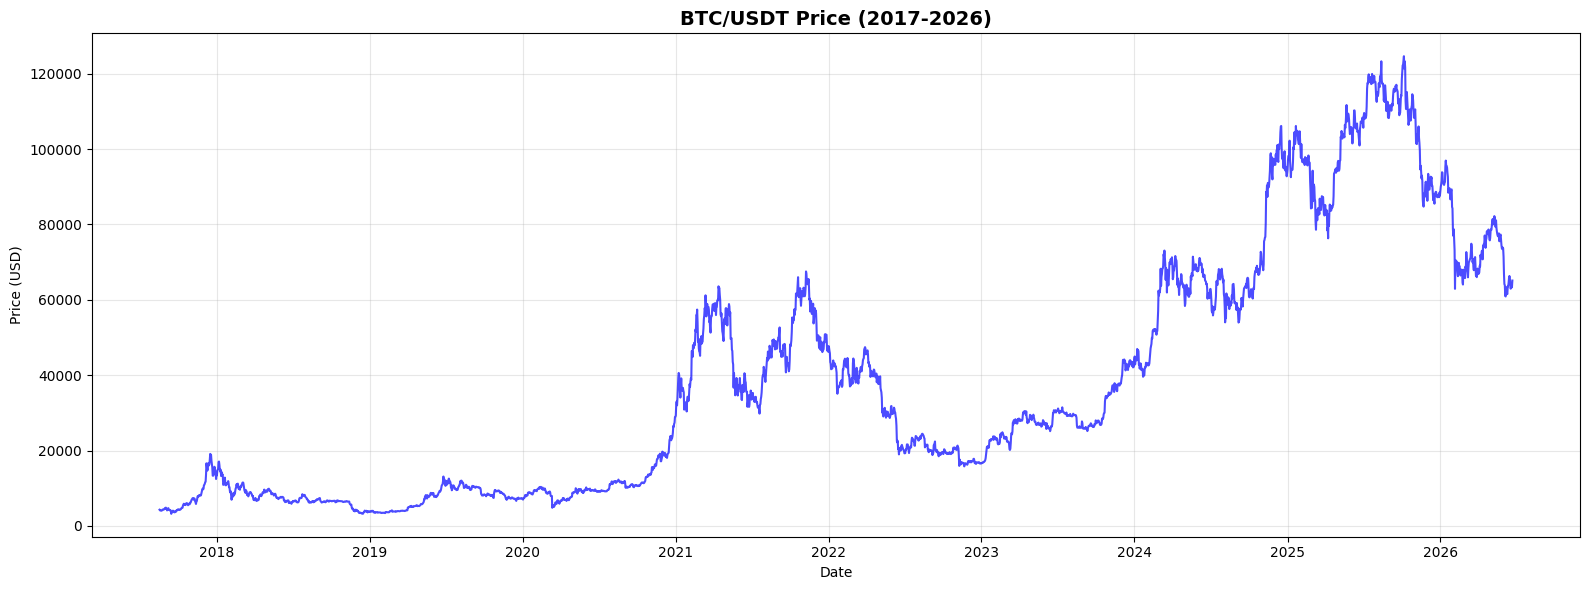

In [6]:
fig, ax = plt.subplots(1, 1, figsize=(16, 6))

ax.plot(df['timestamp'], df['close'], color='blue', alpha=0.7)
ax.set_title('BTC/USDT Price (2017-2026)', fontsize=14, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Price (USD)')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [7]:
df = add_returns(df)
df = add_moving_averages(df, fast=50, slow=200)
df = run_ma_strategy(df, fee=0.001)

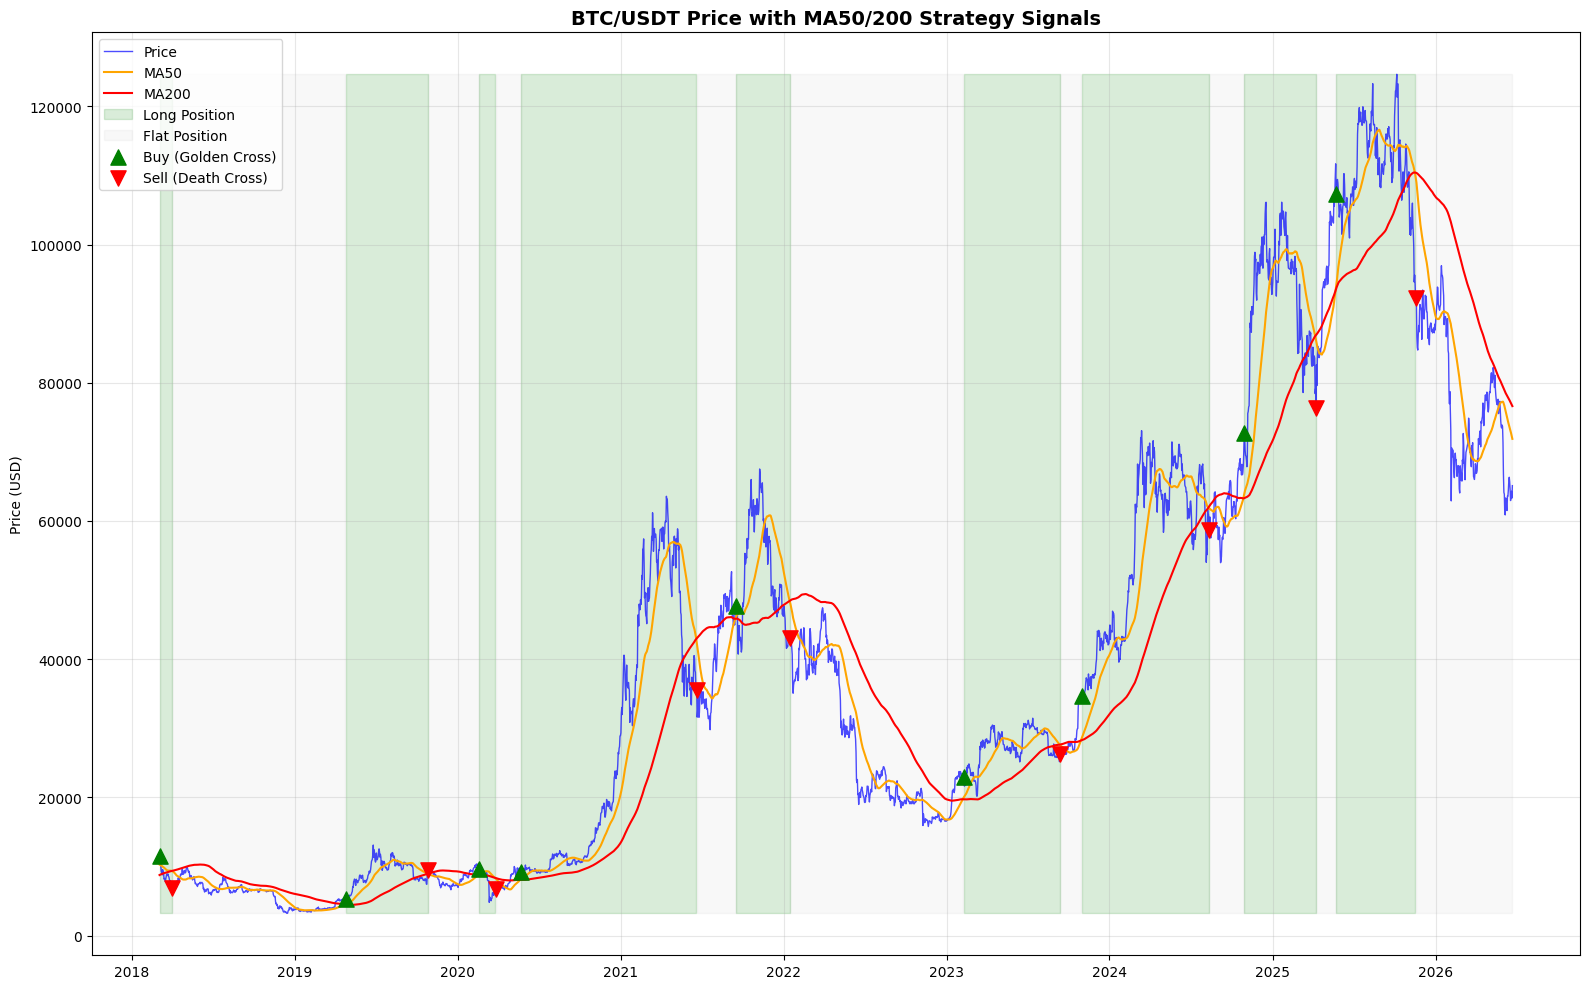

In [8]:
fig, ax1 = plt.subplots(1, 1, figsize=(16, 10))

ax1.plot(df['timestamp'], df['close'], label='Price', color='blue', alpha=0.7, linewidth=1)
ax1.plot(df['timestamp'], df['ma50'], label='MA50', color='orange', linewidth=1.5)
ax1.plot(df['timestamp'], df['ma200'], label='MA200', color='red', linewidth=1.5)


ax1.fill_between(df['timestamp'], df['close'].min(), df['close'].max(),
                 where=df['position'] == 1, alpha=0.15, color='green', label='Long Position')
ax1.fill_between(df['timestamp'], df['close'].min(), df['close'].max(),
                 where=df['position'] == 0, alpha=0.05, color='gray', label='Flat Position')

pos_change = df['position'].diff()
pos_change.iloc[0] = 0

buy_signals  = df[pos_change == 1]
sell_signals = df[pos_change == -1]

ax1.scatter(buy_signals['timestamp'], buy_signals['close'],
            color='green', marker='^', s=120, label='Buy (Golden Cross)', zorder=5)
ax1.scatter(sell_signals['timestamp'], sell_signals['close'],
            color='red', marker='v', s=120, label='Sell (Death Cross)', zorder=5)

ax1.set_title('BTC/USDT Price with MA50/200 Strategy Signals', fontsize=14, fontweight='bold')
ax1.set_ylabel('Price (USD)')
ax1.legend(loc='upper left')
ax1.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [9]:
metrics = pd.DataFrame({
    "MA50/200":   summary(df["strategy_equity"], df["strategy_return"]),
    "Buy & Hold": summary(df["market_equity"],  df["market_return"]),
})
metrics

,MA50/200,Buy & Hold
ROI %,334.36,465.48
Sharpe,0.61,0.65
Sortino,0.60,0.88
Calmar,0.29,0.30
Max Drawdown %,-66.78,-76.63
Win Rate %,26.90,50.77


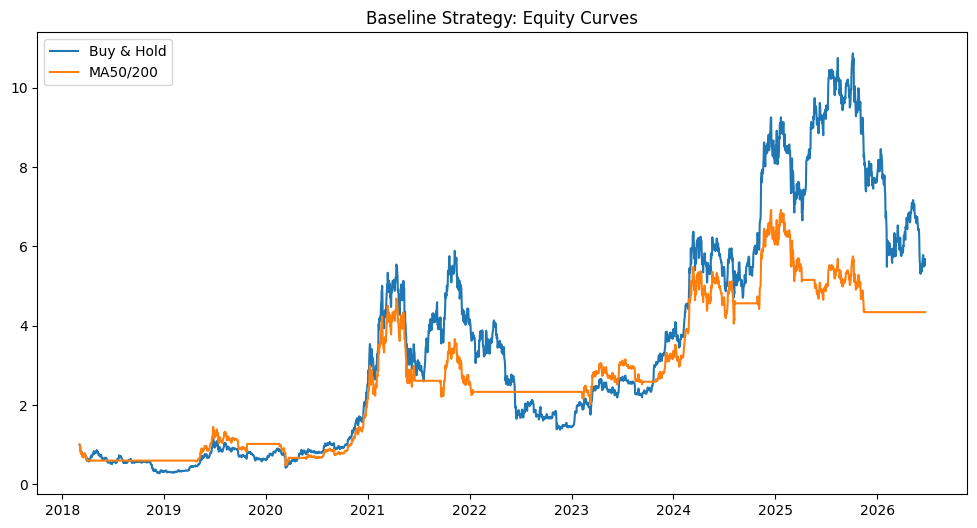

In [10]:
plt.figure(figsize=(12, 6))
plt.plot(df["timestamp"], df["market_equity"], label="Buy & Hold")
plt.plot(df["timestamp"], df["strategy_equity"], label="MA50/200")
plt.legend()
plt.title("Baseline Strategy: Equity Curves")
plt.show()

# Adding AI Agents #

**In this section the strategy will be enhanced by adding new features, ML and time-series model, and adding Agent**
- **features added:** MA50 vs MA200, MACD, Boilenger Width, Vol, Return Lags
- **models used:** LogReg, GradBoost Classifier, RandomForestCLassifier, XGBoostClassifier, ARIMA
- **target:** sign of return

In [11]:
df = load_binance_data_csv()
df = build_features(df)

In [12]:
df.head()

,timestamp,open,high,low,close,volume,market_return,ma50,ma200,rsi,...,return_lag_2,return_lag_3,return_lag_5,hl_range,price_position,volume_change,volume_price_corr,day_of_week,month,target
0,2018-03-04,11464.47,11565.0,11050.02,11515.00,17295.918653,0.004407,10267.6060,8756.49030,60.328106,...,0.010897,0.057447,0.023735,0.044723,0.902909,-0.187495,-0.296407,6,3,0
1,2018-03-05,11515.00,11710.0,11415.01,11454.00,15144.231063,-0.005297,10227.1862,8792.33490,53.155441,...,0.038543,0.010897,-0.022924,0.025754,0.132174,-0.124404,-0.485337,0,3,0
2,2018-03-06,11455.00,11455.0,10555.48,10716.48,29515.572363,-0.064390,10170.7172,8825.37545,45.562339,...,0.004407,0.038543,0.057447,0.083938,0.178984,0.948965,-0.517951,1,3,0
3,2018-03-07,10716.48,10899.0,9389.31,9910.00,50647.671080,-0.075256,10150.9172,8854.22555,45.205519,...,-0.005297,0.004407,0.010897,0.152340,0.344899,0.715964,-0.516309,2,3,0
4,2018-03-08,9910.00,10099.0,9060.00,9271.64,41109.473226,-0.064416,10116.5742,8880.15230,45.108778,...,-0.064390,-0.005297,0.038543,0.112062,0.203696,-0.188325,-0.484904,3,3,0


In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3033 entries, 0 to 3032
Data columns (total 23 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   timestamp          3033 non-null   datetime64[ns]
 1   open               3033 non-null   float64       
 2   high               3033 non-null   float64       
 3   low                3033 non-null   float64       
 4   close              3033 non-null   float64       
 5   volume             3033 non-null   float64       
 6   market_return      3033 non-null   float64       
 7   ma50               3033 non-null   float64       
 8   ma200              3033 non-null   float64       
 9   rsi                3033 non-null   float64       
 10  bb_width           3033 non-null   float64       
 11  volatility         3033 non-null   float64       
 12  return_lag_1       3033 non-null   float64       
 13  return_lag_2       3033 non-null   float64       
 14  return_l

In [14]:
df.describe()

,timestamp,open,high,low,close,volume,market_return,ma50,ma200,rsi,...,return_lag_2,return_lag_3,return_lag_5,hl_range,price_position,volume_change,volume_price_corr,day_of_week,month,target
count,3033,3033.000000,3033.000000,3033.000000,3033.000000,3033.000000,3033.000000,3033.000000,3033.000000,3033.000000,...,3033.000000,3033.000000,3033.000000,3033.000000,3033.000000,3033.000000,3033.000000,3033.000000,3033.000000,3033.000000
mean,2022-04-27 23:59:59.999999744,39909.838220,40725.949298,39030.585767,39927.574507,63255.026399,0.001123,39459.474360,37876.038681,52.042417,...,0.001135,0.001150,0.001155,0.046619,0.532570,0.112627,-0.001367,3.000000,6.446093,0.507418
min,2018-03-04 00:00:00,3211.710000,3276.500000,3156.260000,3211.720000,3104.117220,-0.395048,3619.334600,4435.787850,4.970814,...,-0.395048,-0.395048,-0.395048,0.003391,0.000003,-0.817955,-0.932035,0.000000,1.000000,0.000000
25%,2020-03-31 00:00:00,9706.000000,9937.000000,9464.230000,9706.000000,24622.947794,-0.013492,9423.919400,9182.723800,39.306113,...,-0.013464,-0.013464,-0.013464,0.025217,0.307615,-0.236706,-0.267667,1.000000,4.000000,0.000000
50%,2022-04-28 00:00:00,29888.070000,30445.520000,29294.210000,29895.430000,39692.416542,0.000329,28806.217800,28266.529850,51.600651,...,0.000374,0.000374,0.000374,0.038339,0.545371,-0.014454,0.011664,3.000000,6.000000,1.000000
75%,2024-05-25 00:00:00,62959.530000,64117.090000,61322.220000,63074.010000,66060.834292,0.015052,61705.242200,53175.168950,64.361512,...,0.015052,0.015120,0.015134,0.056975,0.765422,0.322681,0.289459,5.000000,9.000000,1.000000
max,2026-06-22 00:00:00,124658.540000,126199.630000,123084.000000,124658.540000,760705.362783,0.195361,116632.120400,110444.916800,99.426709,...,0.195361,0.195361,0.195361,0.740869,0.998298,5.342227,0.942280,6.000000,12.000000,1.000000
std,NaN,32615.067318,33136.143146,32048.489937,32614.187157,76771.681438,0.032931,32387.347297,31365.172843,17.875687,...,0.032934,0.032949,0.032951,0.035019,0.264371,0.574158,0.378275,2.001154,3.414593,0.500027


In [15]:
EXCLUDE_COLUMNS = ['timestamp', 'target', 'market_return', 'open', 'high', 'low', 'close', 'volume']
FEATURE_COLUMNS = [col for col in df.columns if col not in EXCLUDE_COLUMNS]
print(FEATURE_COLUMNS)

['ma50', 'ma200', 'rsi', 'bb_width', 'volatility', 'return_lag_1', 'return_lag_2', 'return_lag_3', 'return_lag_5', 'hl_range', 'price_position', 'volume_change', 'volume_price_corr', 'day_of_week', 'month']


In [16]:
train, test = chronological_split(df, train_ratio=0.7)

In [17]:
models = {
    'LogReg': make_logreg_gridsearch(),
    'GradBoosting': make_gradient_boosting_gridsearch(),
    'RandomForest': make_random_forest_gridsearch(),
    'XGBoost': make_xgboost_gridsearch(),
}

results = {}
test_results = {}
backtest_results = {}

for name, model in models.items():
    test_pred, trained_model, best_score, best_params = train_and_predict(
        model, train, test, FEATURE_COLUMNS
    )
    
    test_results[name] = test_pred
    
    bt = run_ml_strategy(test_pred)
    backtest_results[name] = bt
    results[name] = summary(bt["strategy_equity"], bt["strategy_return"])

results_df = pd.DataFrame(results).T

In [18]:
classification_metrics = []
for name, test_df in test_results.items():
    metrics = evaluate_classification_model(test_df, name)
    classification_metrics.append(metrics)

print("\n" + "="*80)
print("CLASSIFICATION METRICS ON TEST SET")
print("="*80)
metrics_df = pd.DataFrame(classification_metrics)
print(metrics_df.to_string(index=False))


print("\n" + "="*80)
print("FULL COMPARISON TABLE")
print("="*80)

# Создаем full_comparison
full_comparison = results_df.copy()

# Добавляем классификационные метрики
full_comparison['Accuracy'] = metrics_df.set_index('Model')['Accuracy']
full_comparison['ROC AUC'] = metrics_df.set_index('Model')['ROC AUC']
full_comparison['Precision'] = metrics_df.set_index('Model')['Precision']
full_comparison['Recall'] = metrics_df.set_index('Model')['Recall']
full_comparison['F1 Score'] = metrics_df.set_index('Model')['F1 Score']

print(full_comparison.round(4))



CLASSIFICATION METRICS ON TEST SET
       Model  Accuracy  Precision   Recall  F1 Score  ROC AUC
      LogReg  0.512088   0.575758 0.124183  0.204301 0.534088
GradBoosting  0.520879   0.529412 0.450980  0.487059 0.512364
RandomForest  0.521978   0.564516 0.228758  0.325581 0.508485
     XGBoost  0.506593   0.513089 0.427015  0.466112 0.504454

FULL COMPARISON TABLE
              ROI %  Sharpe  Sortino  Calmar  Max Drawdown %  Win Rate %  \
LogReg        31.45    0.60     0.41    0.71          -16.47        5.95   
GradBoosting  -5.05    0.11     0.13   -0.05          -43.36       21.70   
RandomForest  30.18    0.52     0.42    0.38          -29.27       11.12   
XGBoost      -27.18   -0.21    -0.23   -0.26          -45.60       20.81   

              Accuracy  ROC AUC  Precision  Recall  F1 Score  
LogReg          0.5121   0.5341     0.5758  0.1242    0.2043  
GradBoosting    0.5209   0.5124     0.5294  0.4510    0.4871  
RandomForest    0.5220   0.5085     0.5645  0.2288    0.3256 

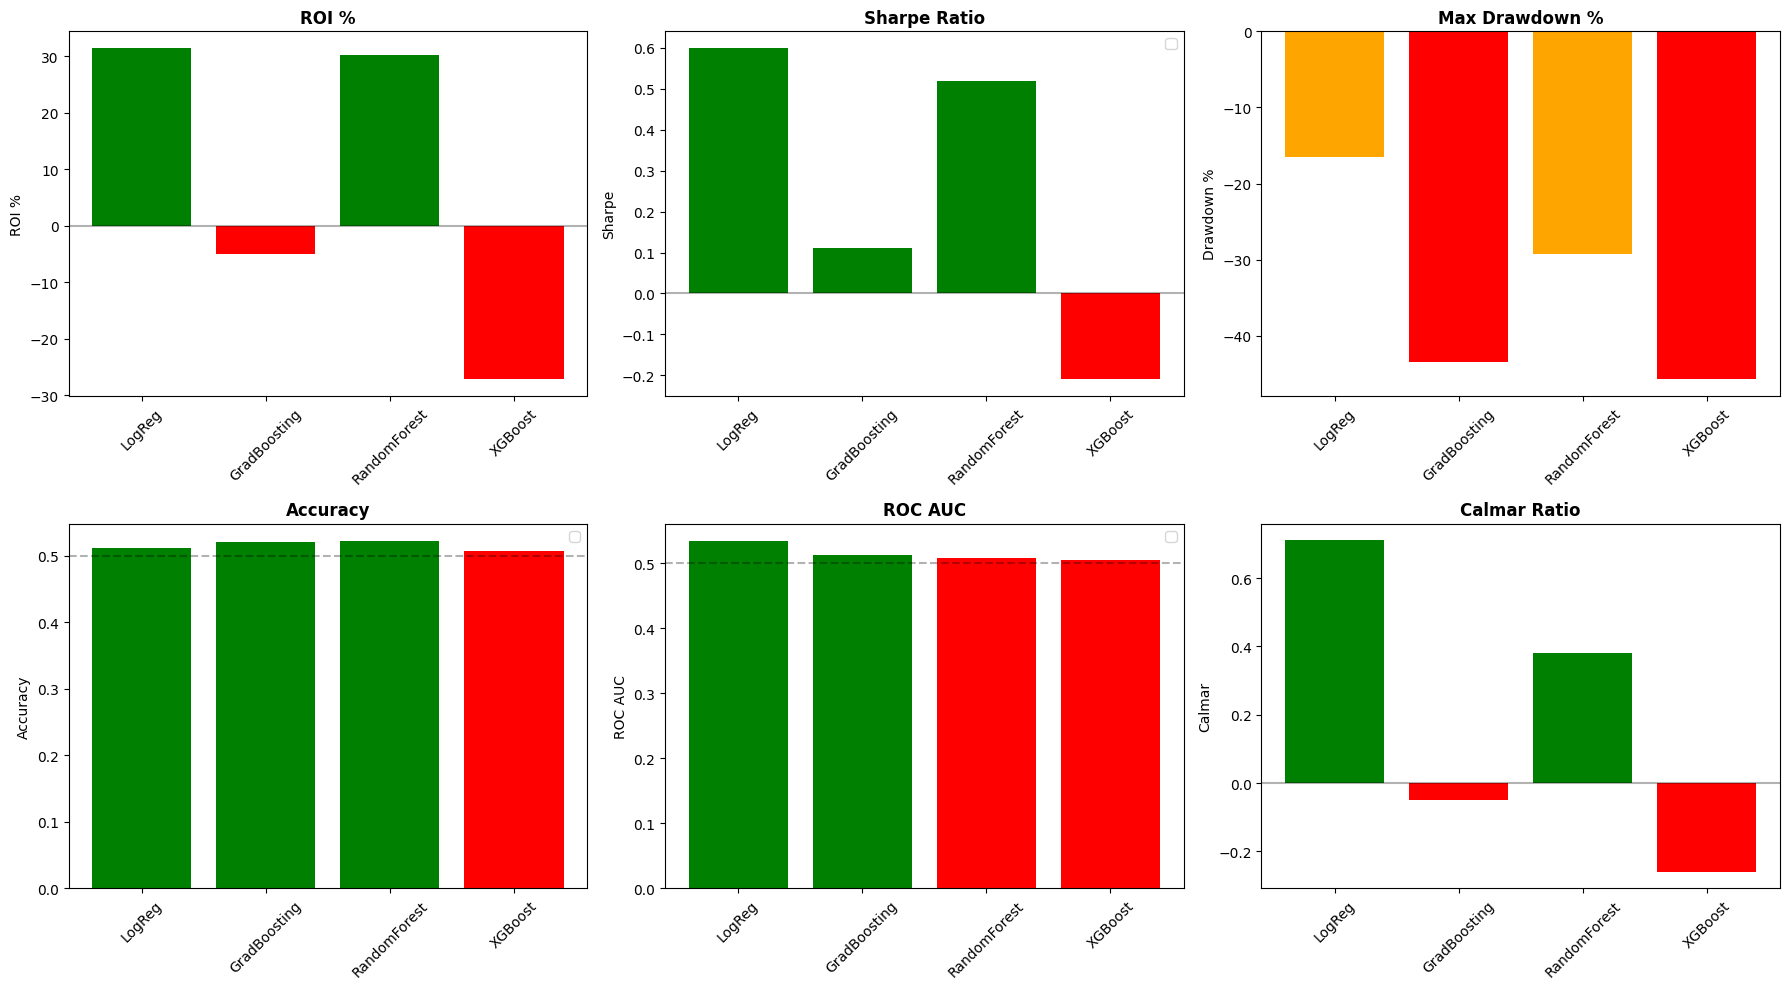

In [19]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# 1. ROI
ax1 = axes[0, 0]
colors = ['green' if x > 0 else 'red' for x in full_comparison['ROI %']]
ax1.bar(full_comparison.index, full_comparison['ROI %'], color=colors)
ax1.axhline(0, color='black', linestyle='-', alpha=0.3)
ax1.set_title('ROI %', fontsize=12, fontweight='bold')
ax1.set_ylabel('ROI %')
ax1.tick_params(axis='x', rotation=45)

# 2. Sharpe
ax2 = axes[0, 1]
colors = ['green' if x > 0 else 'red' for x in full_comparison['Sharpe']]
ax2.bar(full_comparison.index, full_comparison['Sharpe'], color=colors)
ax2.axhline(0, color='black', linestyle='-', alpha=0.3)
ax2.set_title('Sharpe Ratio', fontsize=12, fontweight='bold')
ax2.set_ylabel('Sharpe')
ax2.tick_params(axis='x', rotation=45)
ax2.legend()

# 3. Max Drawdown
ax3 = axes[0, 2]
colors = ['orange' if x > -30 else 'red' for x in full_comparison['Max Drawdown %']]
ax3.bar(full_comparison.index, full_comparison['Max Drawdown %'], color=colors)
ax3.set_title('Max Drawdown %', fontsize=12, fontweight='bold')
ax3.set_ylabel('Drawdown %')
ax3.tick_params(axis='x', rotation=45)

# 4. Accuracy
ax4 = axes[1, 0]
colors = ['green' if x > 0.51 else 'red' for x in full_comparison['Accuracy']]
ax4.bar(full_comparison.index, full_comparison['Accuracy'], color=colors)
ax4.axhline(0.5, color='black', linestyle='--', alpha=0.3)
ax4.set_title('Accuracy', fontsize=12, fontweight='bold')
ax4.set_ylabel('Accuracy')
ax4.tick_params(axis='x', rotation=45)
ax4.legend()

# 5. ROC AUC
ax5 = axes[1, 1]
colors = ['green' if x > 0.51 else 'red' for x in full_comparison['ROC AUC']]
ax5.bar(full_comparison.index, full_comparison['ROC AUC'], color=colors)
ax5.axhline(0.5, color='black', linestyle='--', alpha=0.3)
ax5.set_title('ROC AUC', fontsize=12, fontweight='bold')
ax5.set_ylabel('ROC AUC')
ax5.tick_params(axis='x', rotation=45)
ax5.legend()

# 6. Calmar
ax6 = axes[1, 2]
colors = ['green' if x > 0 else 'red' for x in full_comparison['Calmar']]
ax6.bar(full_comparison.index, full_comparison['Calmar'], color=colors)
ax6.axhline(0, color='black', linestyle='-', alpha=0.3)
ax6.set_title('Calmar Ratio', fontsize=12, fontweight='bold')
ax6.set_ylabel('Calmar')
ax6.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


BEST MODEL: LogReg
ROI: 31.45%
Sharpe: 0.600
Accuracy: 0.5121
ROC AUC: 0.5341


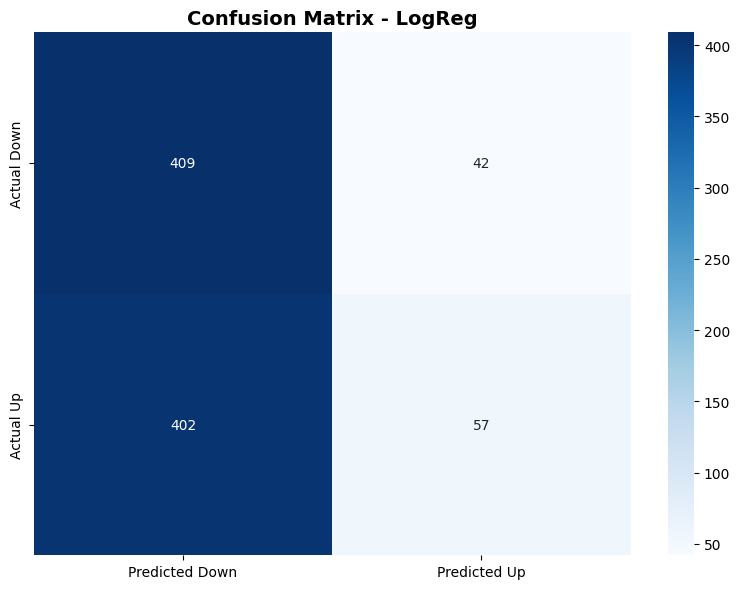

In [20]:
best_model_name = full_comparison['ROI %'].idxmax()
print(f"\n{'='*80}")
print(f"BEST MODEL: {best_model_name}")
print(f"ROI: {full_comparison.loc[best_model_name, 'ROI %']:.2f}%")
print(f"Sharpe: {full_comparison.loc[best_model_name, 'Sharpe']:.3f}")
print(f"Accuracy: {full_comparison.loc[best_model_name, 'Accuracy']:.4f}")
print(f"ROC AUC: {full_comparison.loc[best_model_name, 'ROC AUC']:.4f}")

if best_model_name in test_results:
    best_test = test_results[best_model_name]
    y_true = best_test['target']
    y_pred = best_test['pred']
    
    cm = confusion_matrix(y_true, y_pred)
    
    fig, ax = plt.subplots(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Predicted Down', 'Predicted Up'],
                yticklabels=['Actual Down', 'Actual Up'])
    ax.set_title(f'Confusion Matrix - {best_model_name}', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

In [21]:
test_arima = test.copy()
test_arima["pred"] = arima_signal(train["market_return"], test["market_return"])
bt_arima = run_ml_strategy(test_arima)

results["ARIMA"] = summary(bt_arima["strategy_equity"], bt_arima["strategy_return"])
pd.DataFrame(results).T

C:\Users\pda95\PycharmProjects\ai-crypto-hedge-fund\.venv\lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\pda95\PycharmProjects\ai-crypto-hedge-fund\.venv\lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\pda95\PycharmProjects\ai-crypto-hedge-fund\.venv\lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\pda95\PycharmProjects\ai-crypto-hedge-fund\.venv\lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Like

,ROI %,Sharpe,Sortino,Calmar,Max Drawdown %,Win Rate %
LogReg,31.45,0.60,0.41,0.71,-16.47,5.95
GradBoosting,-5.05,0.11,0.13,-0.05,-43.36,21.70
RandomForest,30.18,0.52,0.42,0.38,-29.27,11.12
XGBoost,-27.18,-0.21,-0.23,-0.26,-45.60,20.81
ARIMA,-30.37,-0.16,-0.24,-0.23,-60.02,38.55


In [22]:
agent = TradingAgent()
test_agent= agent.decide(test_results['LogReg'])
bt_agent = run_agent_strategy(test_agent)
results['TradingAgent'] = summary(bt_agent["strategy_equity"], bt_agent["strategy_return"])
pd.DataFrame(results).T

,ROI %,Sharpe,Sortino,Calmar,Max Drawdown %,Win Rate %
LogReg,31.45,0.60,0.41,0.71,-16.47,5.95
GradBoosting,-5.05,0.11,0.13,-0.05,-43.36,21.70
RandomForest,30.18,0.52,0.42,0.38,-29.27,11.12
XGBoost,-27.18,-0.21,-0.23,-0.26,-45.60,20.81
ARIMA,-30.37,-0.16,-0.24,-0.23,-60.02,38.55
TradingAgent,10.12,0.94,1.00,2.19,-1.80,5.62


# Portfolio Management on Historical Data

**In this section the Markowitz Portfolio Theory was implemented**

In [23]:
prices = load_portfolio_data()
returns = compute_returns(prices)

In [24]:
mean_returns = returns.mean()
cov_matrix = returns.cov()
assets = list(prices.columns)

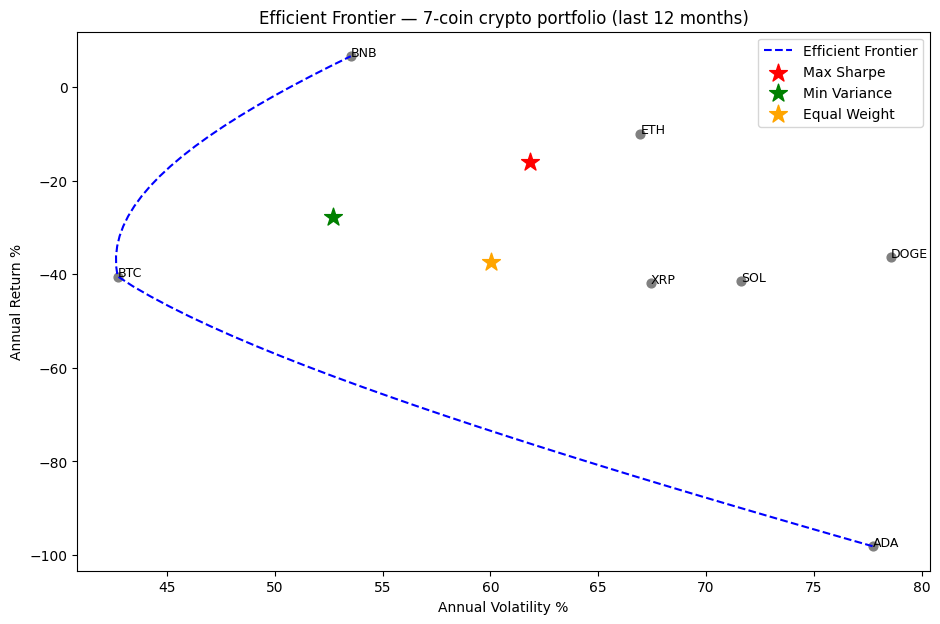

In [25]:
w_sharpe = optimize_max_sharpe(mean_returns, cov_matrix)
w_minvar = optimize_min_variance(mean_returns, cov_matrix)
w_equal  = np.array([1/len(assets)] * len(assets))

rows = {}
for name, w in [("Max Sharpe", w_sharpe), ("Min Variance", w_minvar), ("Equal Weight", w_equal)]:
    ret, vol = portfolio_performance(w, mean_returns, cov_matrix)
    rows[name] = {"Return %": round(ret*100, 1),
                  "Volatility %": round(vol*100, 1),
                  "Sharpe": round(ret/vol, 2)}

ef = efficient_frontier(mean_returns, cov_matrix)

plt.figure(figsize=(11, 7))
plt.plot(ef[:, 0]*100, ef[:, 1]*100, "b--", label="Efficient Frontier")

for name, w, color in [("Max Sharpe", w_sharpe, "red"),
                       ("Min Variance", w_minvar, "green"),
                       ("Equal Weight", w_equal, "orange")]:
    ret, vol = portfolio_performance(w, mean_returns, cov_matrix)
    plt.scatter(vol*100, ret*100, c=color, s=180, marker="*", label=name, zorder=5)


for a in assets:
    r = mean_returns[a]*PERIODS_PER_YEAR*100
    v = np.sqrt(cov_matrix.loc[a, a])*np.sqrt(PERIODS_PER_YEAR)*100
    plt.scatter(v, r, c="gray", s=40)
    plt.annotate(a, (v, r), fontsize=9)

plt.xlabel("Annual Volatility %")
plt.ylabel("Annual Return %")
plt.title("Efficient Frontier — 7-coin crypto portfolio (last 12 months)")
plt.legend()
plt.show()


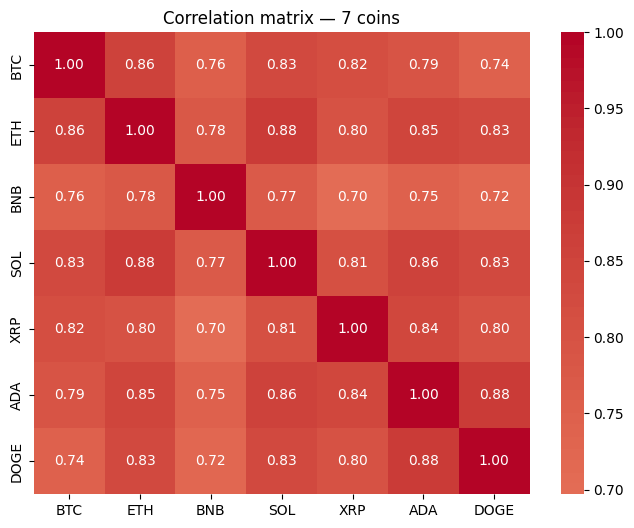

In [26]:
plt.figure(figsize=(8, 6))
sns.heatmap(returns.corr(), annot=True, cmap="coolwarm", center=0, fmt=".2f")
plt.title("Correlation matrix — 7 coins")
plt.show()

In [27]:
split = len(returns) // 2
train_ret = returns.iloc[:split]
test_ret  = returns.iloc[split:]

w_oos = optimize_max_sharpe(train_ret.mean(), train_ret.cov())
oos_daily = (test_ret * w_oos).sum(axis=1)
oos_total = (1 + oos_daily).prod() - 1
print(f"Max Sharpe веса (на train): {dict(zip(assets, (w_oos*100).round(1)))}")
print(f"Out-of-sample доходность на test-периоде: {oos_total*100:.1f}%")

Max Sharpe веса (на train): {'BTC': np.float64(0.0), 'ETH': np.float64(30.0), 'BNB': np.float64(30.0), 'SOL': np.float64(10.0), 'XRP': np.float64(30.0), 'ADA': np.float64(0.0), 'DOGE': np.float64(0.0)}
Out-of-sample доходность на test-периоде: -37.6%


# Dynamic Portfolio Rebalancing

**In this section the Markowitz Portfolio Theory with Dynamic Rebalancing was implemented**

                Rebalance Monthly (MaxSharpe)  Rebalance Weekly (MaxSharpe)  \
ROI %                                  -58.27                        -58.55   
Sharpe                                  -1.76                         -1.80   
Sortino                                 -2.46                         -2.52   
Calmar                                  -1.04                         -1.06   
Max Drawdown %                         -65.95                        -65.43   
Win Rate %                              47.81                         46.72   

                Rebalance Monthly (1/N)  Static Buy&Hold (Level 3)  
ROI %                            -60.34                     -50.54  
Sharpe                            -1.81                      -1.46  
Sortino                           -2.56                      -1.98  
Calmar                            -1.07                      -1.00  
Max Drawdown %                   -66.27                     -60.91  
Win Rate %                      

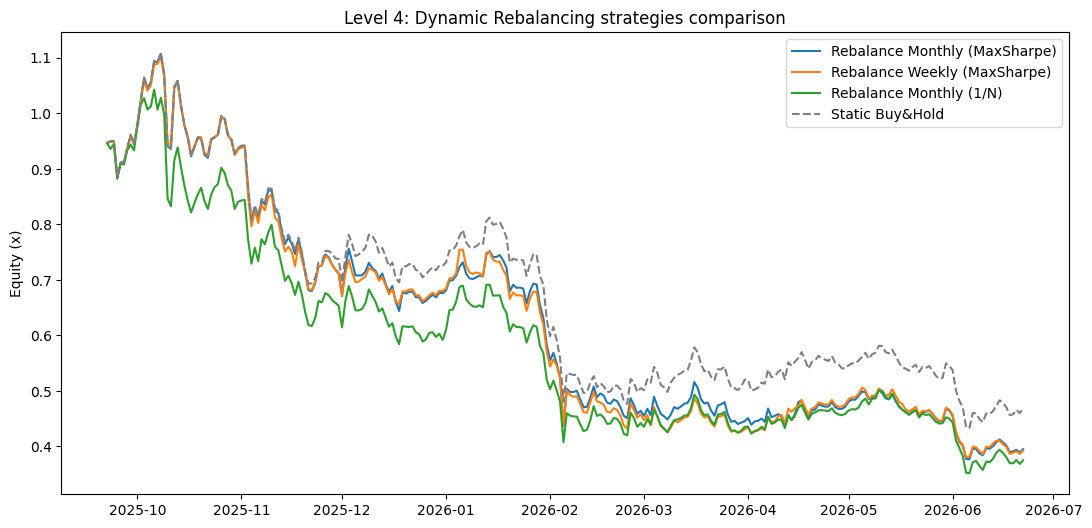

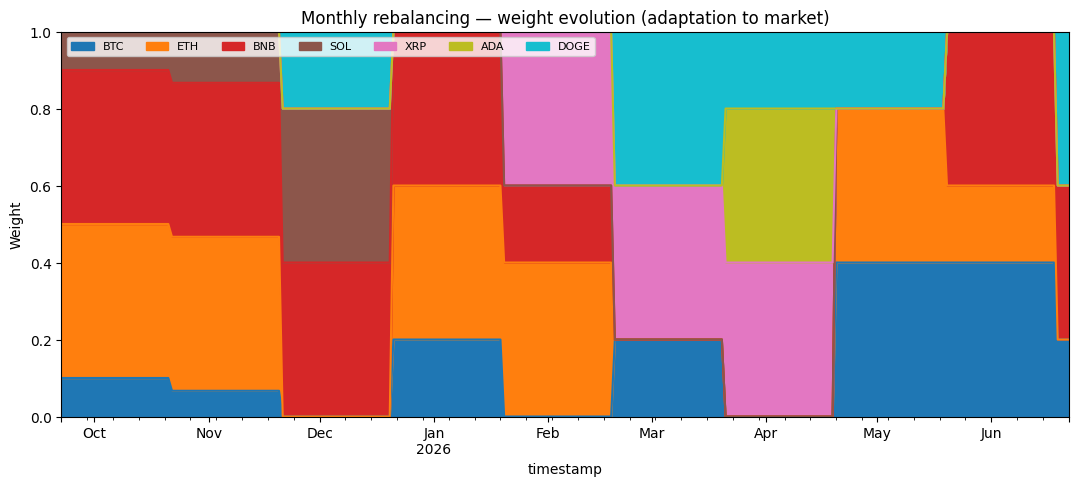

In [28]:
from src.data_loader import load_portfolio_data
from src.portfolio import compute_returns
from src.rebalance import backtest_rebalanced, buy_and_hold_weights
from src.metrics import summary
import pandas as pd
import matplotlib.pyplot as plt

prices = load_portfolio_data()
returns = compute_returns(prices)

# --- Три схемы ребалансировки + статический бенчмарк ---
eq_monthly, r_monthly, w_monthly = backtest_rebalanced(returns, rebal_freq=30, strategy="max_sharpe")
eq_weekly,  r_weekly,  w_weekly  = backtest_rebalanced(returns, rebal_freq=7,  strategy="max_sharpe")
eq_equal,   r_equal,   _         = backtest_rebalanced(returns, rebal_freq=30, strategy="equal_weight")
eq_hold,    r_hold              = buy_and_hold_weights(returns)

# --- Сравнительная таблица ---
results = pd.DataFrame({
    "Rebalance Monthly (MaxSharpe)": summary(eq_monthly, r_monthly),
    "Rebalance Weekly (MaxSharpe)":  summary(eq_weekly,  r_weekly),
    "Rebalance Monthly (1/N)":       summary(eq_equal,   r_equal),
    "Static Buy&Hold (Level 3)":     summary(eq_hold,    r_hold),
})
print(results)

# --- Equity-кривые ---
plt.figure(figsize=(13, 6))
plt.plot(eq_monthly, label="Rebalance Monthly (MaxSharpe)")
plt.plot(eq_weekly,  label="Rebalance Weekly (MaxSharpe)")
plt.plot(eq_equal,   label="Rebalance Monthly (1/N)")
plt.plot(eq_hold,    label="Static Buy&Hold", ls="--", color="gray")
plt.title("Level 4: Dynamic Rebalancing strategies comparison")
plt.ylabel("Equity (x)")
plt.legend()
plt.show()

# --- Как менялись веса во времени (адаптация к рынку) ---
w_monthly.plot.area(figsize=(13, 5), cmap="tab10")
plt.title("Monthly rebalancing — weight evolution (adaptation to market)")
plt.ylabel("Weight")
plt.ylim(0, 1)
plt.legend(loc="upper left", ncol=7, fontsize=8)
plt.show()


In [29]:
# Запуск
eq_riskoff, r_riskoff = backtest_with_risk_off(
    returns,
    drawdown_threshold=-0.15,
    vol_threshold=0.04
)
results["Risk-Off (dd>15%)"] = summary(eq_riskoff, r_riskoff)
print(pd.DataFrame(results).T)

                               ROI %  Sharpe  Sortino  Calmar  Max Drawdown %  \
Rebalance Monthly (MaxSharpe) -58.27   -1.76    -2.46   -1.04          -65.95   
Rebalance Weekly (MaxSharpe)  -58.55   -1.80    -2.52   -1.06          -65.43   
Rebalance Monthly (1/N)       -60.34   -1.81    -2.56   -1.07          -66.27   
Static Buy&Hold (Level 3)     -50.54   -1.46    -1.98   -1.00          -60.91   
Risk-Off (dd>15%)              19.66    1.11     0.60    1.14          -17.34   

                               Win Rate %  
Rebalance Monthly (MaxSharpe)       47.81  
Rebalance Weekly (MaxSharpe)        46.72  
Rebalance Monthly (1/N)             45.62  
Static Buy&Hold (Level 3)           47.08  
Risk-Off (dd>15%)                    6.61  


# Portfolio Expansion

**In this section the Portfolio Theory is studied through enhanced data of cryptopairs**
- **Numbers of cryptopairs is not equal to 100 because of the cleaning of data on the data_loading step from ccxt.binance().**
- **data_loading and cleaning is not included in this project.
Cleaning logic - skip cryptopairs with >20% of missing 1d ohlcv data**

In [30]:
from src.data_loader import load_top_100_pairs
prices = load_top_100_pairs()
print(f"Загружено: {prices.shape[1]} монет, {prices.shape[0]} дней")
print(prices.columns.tolist())

Загружено: 80 монет, 295 дней
['BTC', 'ETH', 'USD1', 'SOL', 'WLD', 'XRP', 'ZEC', 'TAO', 'BNB', 'NEAR', 'SYN', 'TRX', 'TNSR', 'RESOLV', 'ENA', 'SUI', 'TRUMP', 'DOGE', 'SAGA', 'ID', 'AVAX', 'ADA', 'BICO', 'EIGEN', 'FET', 'XLM', 'EUR', 'STO', 'HMSTR', 'UTK', 'LTC', 'LINK', 'TON', 'PEPE', 'UNI', 'STRAX', 'AAVE', 'BEL', 'ONDO', 'PAXG', 'W', 'BFUSD', 'FIL', 'HOME', 'JTO', 'IO', 'ALICE', 'INJ', 'DEXE', 'AXS', 'HBAR', 'ZRO', 'DYM', 'APT', 'DASH', 'DOT', 'ICP', 'PENGU', 'RENDER', 'WLFI', 'PENDLE', 'BCH', 'SPK', 'VIC', 'EPIC', 'BIO', 'TIA', 'CHZ', 'ORDI', 'ARB', 'BROCCOLI714', 'NEIRO', 'WBTC', 'POL', 'XAI', 'JST', 'SEI', 'DYDX', 'ACE', 'BANANAS31']


In [31]:
prices = load_top_100_pairs()

EXCLUDE = {
    "USD1", "BFUSD", "EUR", "USDC", "BUSD", "TUSD", "FDUSD", "DAI", "USDP",
    "PAXG",
    "WBTC"
}
prices = prices.drop(columns=[c for c in EXCLUDE if c in prices.columns])

returns = prices.pct_change().dropna()

diag = pd.DataFrame({
    "daily_vol":   returns.std(),
    "mean_ret":    returns.mean(),
    "zero_days":   (returns == 0).sum(),
    "max_1d_move": returns.abs().max(),
})
diag["zero_pct"] = (diag["zero_days"] / len(returns) * 100).round(1)

print(f"Монет после базовой чистки: {prices.shape[1]}")
print("\n--- Потенциально проблемные (почти нулевая волатильность) ---")
print(diag[diag["daily_vol"] < 0.005].sort_values("daily_vol"))

print("\n--- Потенциально проблемные (>10% дней с нулевым движением = forward-fill) ---")
print(diag[diag["zero_pct"] > 10].sort_values("zero_pct", ascending=False))

print("\n--- Экстремальная волатильность (возможные пампы/скам) ---")
print(diag[diag["max_1d_move"] > 0.50].sort_values("max_1d_move", ascending=False))


Монет после базовой чистки: 75

--- Потенциально проблемные (почти нулевая волатильность) ---
Empty DataFrame
Columns: [daily_vol, mean_ret, zero_days, max_1d_move, zero_pct]
Index: []

--- Потенциально проблемные (>10% дней с нулевым движением = forward-fill) ---
     daily_vol  mean_ret  zero_days  max_1d_move  zero_pct
UTK   0.040912 -0.003443         70     0.296174      23.8

--- Экстремальная волатильность (возможные пампы/скам) ---
             daily_vol  mean_ret  zero_days  max_1d_move  zero_pct
TNSR          0.170641  0.005268          4     2.211929       1.4
ORDI          0.111954  0.001346          1     1.473287       0.3
STO           0.115082  0.003756          2     1.242743       0.7
BICO          0.082560 -0.000281          4     0.806122       1.4
FIL           0.069668 -0.001505          4     0.791865       1.4
DYM           0.079142 -0.005250          9     0.774074       3.1
SAGA          0.078355 -0.006133          7     0.700115       2.4
BANANAS31     0.09647

In [32]:
clean_prices = clean_universe(prices)
clean_returns = clean_prices.pct_change().dropna()

In [33]:
funnel = {
    "Requested (by liquidity)": 100,
    "Have 1y history": 80,
    "After removing stables/wrapped": 75,
    "After quality filters (tradable)": 63,
}
print(pd.Series(funnel, name="pairs"))

Requested (by liquidity)            100
Have 1y history                      80
After removing stables/wrapped       75
After quality filters (tradable)     63
Name: pairs, dtype: int64


In [34]:
corr = clean_returns.corr()
mask = ~np.eye(len(corr), dtype=bool)
avg_corr = corr.values[mask].mean()
print(f"Средняя попарная корреляция (63 монеты): {avg_corr:.2f}")
print(f"Медианная корреляция: {np.median(corr.values[mask]):.2f}")
print(f"Доля пар с корреляцией > 0.7: {(corr.values[mask] > 0.7).mean()*100:.1f}%")

Средняя попарная корреляция (63 монеты): 0.49
Медианная корреляция: 0.50
Доля пар с корреляцией > 0.7: 16.9%


In [35]:
groups = correlation_groups(clean_returns, threshold=0.7)
print(f"=== CORRELATION GROUPS: {len(groups)} кластеров из 63 монет ===")
print(f"Крупнейший кластер: {len(max(groups, key=len))} монет")

# --- 3. Приоритизация сигналов (демо на синтетических сигналах для 63 монет) ---
np.random.seed(42)
signals = pd.DataFrame({
    "symbol": clean_returns.columns,
    "signal_strength": np.random.uniform(-1, 1, 63),
    "confidence": np.random.uniform(0.3, 0.9, 63),
    "volatility": clean_returns.std().values,
    "liquidity_score": np.random.uniform(0.5, 1.0, 63),
})

top = prioritize_signals(signals, top_k=20)
print(f"=== SIGNAL PRIORITIZATION: 63 сигнала -> топ-{len(top)} ===")
print(top[["symbol", "priority"]].head(10).to_string(index=False), "\n")

# --- 4. Риск-агент: режет веса по лимитам ---
raw_weights = np.random.dirichlet(np.ones(63))  # сырые веса
agent = RiskAgent()
adj_w, risk_off = agent.apply(raw_weights, groups, list(clean_returns.columns),
                              portfolio_vol=0.06, current_drawdown=-0.10)
print("=== RISK AGENT ===")
print(f"Макс. вес до: {raw_weights.max():.1%} -> после лимита: {adj_w.max():.1%}")
print(f"Суммарная экспозиция после vol-targeting: {adj_w.sum():.1%}\n")

# --- 5. Fail-safe: стресс-сценарий (агент "сошёл с ума") ---
print("=== FAIL-SAFE STRESS TEST ===")
normal = {"daily_pnl": -0.02, "drawdown": -0.05, "turnover": 0.3,
          "max_position": 0.08, "data_ok": True}
crazy  = {"daily_pnl": -0.12, "drawdown": -0.30, "turnover": 5.0,
          "max_position": 0.40, "data_ok": False}
limits = {"max_daily_loss": 0.08, "max_drawdown": 0.25,
          "max_turnover": 2.0, "max_position": 0.15}
print("Normal:", fail_safe_check(normal, limits))
print("Anomaly:", fail_safe_check(crazy, limits))


=== CORRELATION GROUPS: 37 кластеров из 63 монет ===
Крупнейший кластер: 17 монет
=== SIGNAL PRIORITIZATION: 63 сигнала -> топ-20 ===
symbol  priority
   BNB 15.050466
   SUI 12.194120
   TIA 12.127647
   POL 11.559359
   ETH 11.532392
   XRP 11.147686
  DOGE 10.971580
   ENA 10.295155
  EPIC  8.261601
     W  8.038806 

=== RISK AGENT ===
Макс. вес до: 5.3% -> после лимита: 1.8%
Суммарная экспозиция после vol-targeting: 33.3%

=== FAIL-SAFE STRESS TEST ===
Normal: ('NORMAL', [])
Anomaly: ('HALT', ['MAX DAILY LOSS -> HALT', 'MAX DRAWDOWN -> DE-RISK', 'ABNORMAL TURNOVER -> HALT', 'POSITION LIMIT -> HALT', 'DATA FEED FAILURE -> HALT'])
